<a href="https://colab.research.google.com/github/MUKESHKUMAR-21/DeepLearning/blob/main/DL_Exp06.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Using device: cpu
Training BiRNN Model...
Epoch 020/100, Loss: 0.00236
Epoch 040/100, Loss: 0.00232
Epoch 060/100, Loss: 0.00380
Epoch 080/100, Loss: 0.00210
Epoch 100/100, Loss: 0.00301

Training Feedforward NN Model...
Epoch 020/100, Loss: 0.00228
Epoch 040/100, Loss: 0.00137
Epoch 060/100, Loss: 0.00103
Epoch 080/100, Loss: 0.00055
Epoch 100/100, Loss: 0.00052


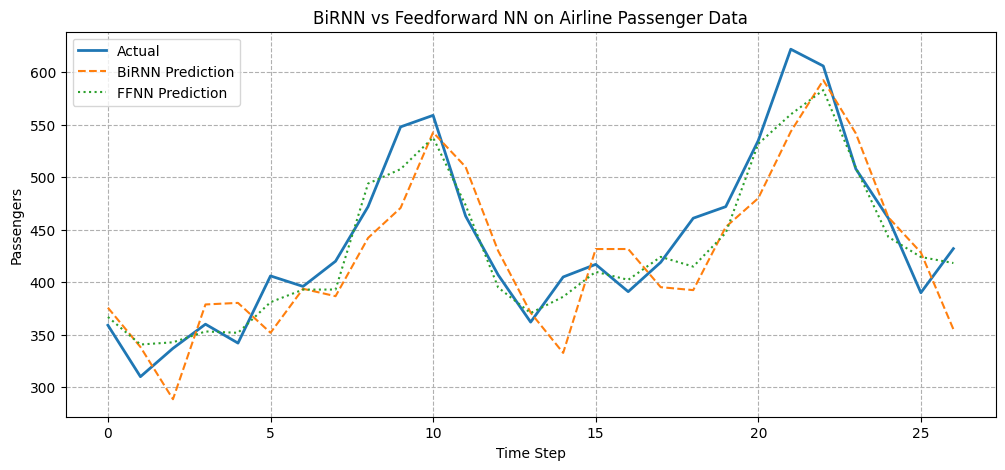


Final Metrics Summary:
BiRNN MSE : 1845.273
FFNN MSE  : 547.664


In [2]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Corrected URL to a raw CSV file for airline passenger data
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv'
df = pd.read_csv(url, usecols=[1])
data = df.values.astype('float32')

scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(data)

SEQ_LENGTH = 10
X = np.array([data_scaled[i:i+SEQ_LENGTH] for i in range(len(data_scaled) - SEQ_LENGTH)])
y = np.array([data_scaled[i + SEQ_LENGTH] for i in range(len(data_scaled) - SEQ_LENGTH)])

train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=16, shuffle=True)

class BiRNN(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=1):
        super(BiRNN, self).__init__()
        self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden_size * 2, 1)

    def forward(self, x):
        out, _ = self.rnn(x)
        return self.fc(out[:, -1, :])

class FeedforwardNN(nn.Module):
    def __init__(self, input_size):
        super(FeedforwardNN, self).__init__()
        self.fc1 = nn.Linear(input_size, 64)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(64, 1)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.fc2(self.relu(self.fc1(x)))

def train_model(model, loader, epochs=100):
    model = model.to(device)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
    model.train()

    for epoch in range(epochs):
        loss_epoch = 0
        for seqs, targets in loader:
            seqs, targets = seqs.to(device), targets.to(device)
            optimizer.zero_grad(set_to_none=True)
            outputs = model(seqs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            loss_epoch += loss.item()

        if (epoch + 1) % 20 == 0:
            print(f"Epoch {epoch+1:03d}/{epochs}, Loss: {loss_epoch / len(loader):.5f}")

def evaluate_model(model, X_tensor):
    model.eval()
    with torch.no_grad():
        return model(X_tensor).cpu().numpy()

print("Training BiRNN Model...")
birnn = BiRNN()
train_model(birnn, train_loader)

print("\nTraining Feedforward NN Model...")
ffnn = FeedforwardNN(input_size=SEQ_LENGTH)
train_model(ffnn, train_loader)

pred_birnn = evaluate_model(birnn, X_test_tensor)
pred_ffnn = evaluate_model(ffnn, X_test_tensor)

pred_birnn_inv = scaler.inverse_transform(pred_birnn)
pred_ffnn_inv = scaler.inverse_transform(pred_ffnn)
y_test_inv = scaler.inverse_transform(y_test)

plt.figure(figsize=(12, 5))
plt.plot(y_test_inv, label='Actual', linewidth=2)
plt.plot(pred_birnn_inv, label='BiRNN Prediction', linestyle='--')
plt.plot(pred_ffnn_inv, label='FFNN Prediction', linestyle=':')
plt.legend()
plt.title('BiRNN vs Feedforward NN on Airline Passenger Data')
plt.xlabel('Time Step')
plt.ylabel('Passengers')
plt.grid(True, linestyle='--')
plt.show()

mse_birnn = mean_squared_error(y_test_inv, pred_birnn_inv)
mse_ffnn = mean_squared_error(y_test_inv, pred_ffnn_inv)

print(f"\nFinal Metrics Summary:")
print(f"BiRNN MSE : {mse_birnn:.3f}")
print(f"FFNN MSE  : {mse_ffnn:.3f}")